<a href="https://colab.research.google.com/github/TatianaTchouakam/moosic-unsupervised-playlist-clustering/blob/main/moosic-unsupervised-playlist-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn import set_config
set_config(transform_output="pandas")
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors

In [ ]:
url = "https://drive.google.com/uc?export=download&id=1oYQSNxfvw6kFr6-N9rKLRAnLXlp0osEt"
songs_df = pd.read_csv(url)
songs_df.shape

(5235, 19)

In [ ]:
songs_df.columns = songs_df.columns.str.strip()
songs_df = songs_df.drop(columns=['Unnamed: 0','mode','duration_ms','time_signature','id', 'html', 'key', 'type'])
songs_df = songs_df.set_index(["name", "artist"])
songs_df.shape

(5235, 9)

In [ ]:
songs_df

,,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
name,artist,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376
Saudade De Bahia,Antônio Carlos Jobim,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039
"Canta Canta, Minha Gente",Martinho Da Vila,0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698
Mulher Eu Sei,Chico César,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802
Rosa Morena,Kurt Elling,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941
...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573


In [ ]:
songs_df = songs_df[~songs_df.duplicated(keep="first")]
print("Shape after removing exact duplicates:", songs_df.shape)

Shape after removing exact duplicates: (5160, 9)


In [ ]:
def compare_scalers(data, k_range=range(2, 16)):

    scalers = {
        "MinMaxScaler": MinMaxScaler(),
        "StandardScaler": StandardScaler(),
        "RobustScaler": RobustScaler()
    }

    all_scores = []
    pca_results = {}

    for scaler_name, scaler in scalers.items():

        scaled_data = scaler.fit_transform(data)

        pca = PCA(n_components=0.95)
        pca_data = pca.fit_transform(scaled_data)

        pca_results[scaler_name] = pca_data

        for k in k_range:
            model = KMeans(n_clusters=k, random_state=42)
            labels = model.fit_predict(pca_data)

            all_scores.append({
                "Scaler": scaler_name,
                "k": k,
                "Inertia": model.inertia_,
                "Silhouette": silhouette_score(pca_data, labels),
                "PCA_components": pca_data.shape[1]
            })

    scores_df = pd.DataFrame(all_scores)

    return scores_df, pca_results

In [ ]:
scores_df, pca_results = compare_scalers(songs_df)
scores_df

,Scaler,k,Inertia,Silhouette,PCA_components
0,MinMaxScaler,2,1725.806567,0.414004,6
1,MinMaxScaler,3,1129.253478,0.395890,6
2,MinMaxScaler,4,881.481152,0.391293,6
3,MinMaxScaler,5,698.002262,0.355544,6
4,MinMaxScaler,6,644.706346,0.299993,6
5,MinMaxScaler,7,586.405691,0.299577,6
6,MinMaxScaler,8,553.807755,0.295129,6
7,MinMaxScaler,9,521.112212,0.302456,6
8,MinMaxScaler,10,498.835987,0.281087,6
9,MinMaxScaler,11,477.582906,0.273237,6


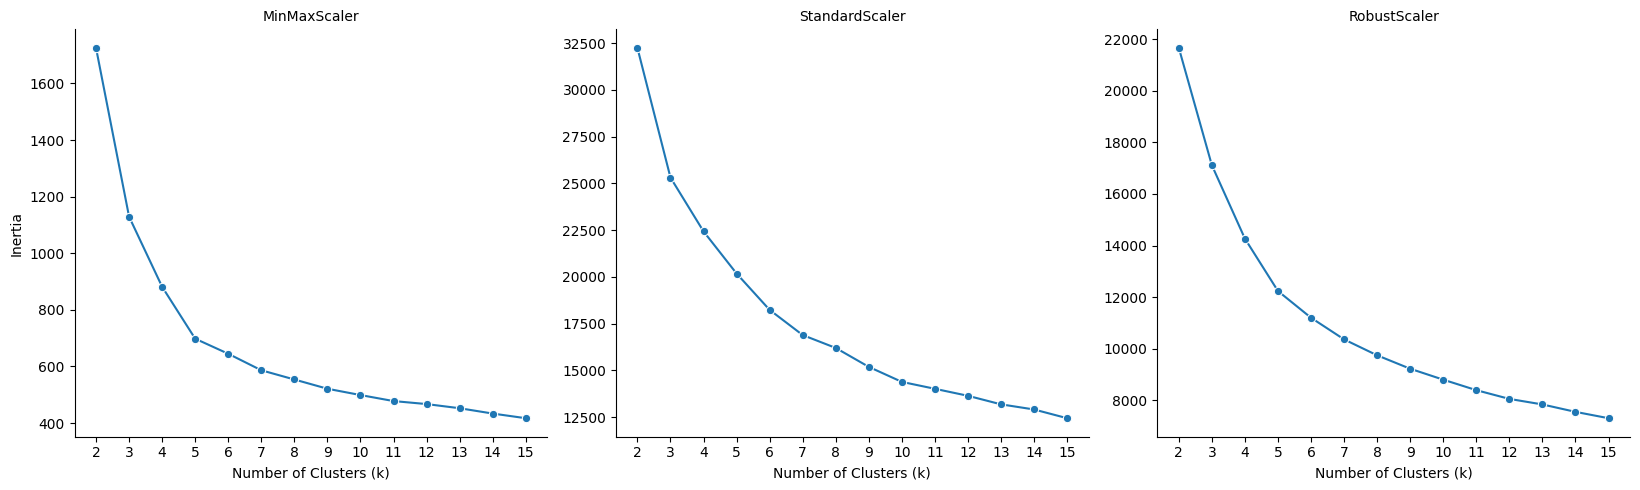

In [ ]:
g = sns.FacetGrid(
    scores_df,
    col="Scaler",
    sharey=False,
    height=5,
    aspect=1.1
)

g.map_dataframe(
    sns.lineplot,
    x="k",
    y="Inertia",
    marker="o"
)

# Force tous les k sur l'axe X
for ax in g.axes.flat:
    ax.set_xticks(range(2,16))

g.set_axis_labels("Number of Clusters (k)", "Inertia")
g.set_titles("{col_name}")

plt.show()

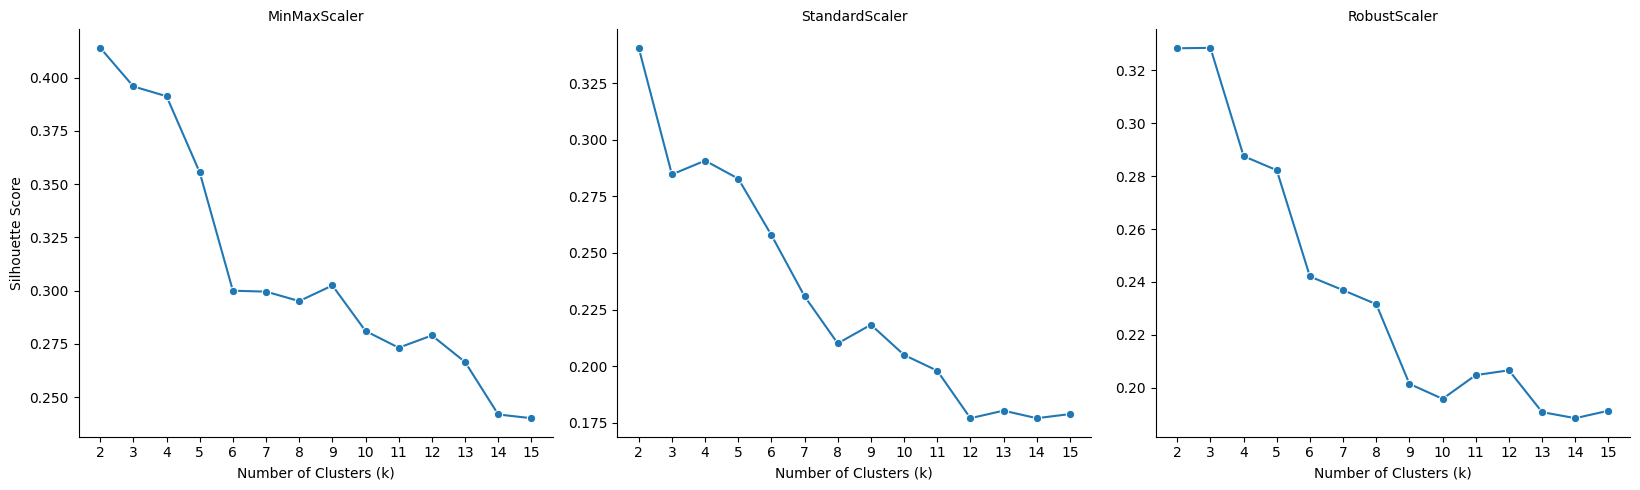

In [ ]:
g = sns.FacetGrid(
    scores_df,
    col="Scaler",
    sharey=False,
    height=5,
    aspect=1.1
)

g.map_dataframe(
    sns.lineplot,
    x="k",
    y="Silhouette",
    marker="o"
)

for ax in g.axes.flat:
    ax.set_xticks(range(2,16))

g.set_axis_labels("Number of Clusters (k)", "Silhouette Score")
g.set_titles("{col_name}")

plt.show()

MinMaxScaler elbow K=5 silhouette K=5
StandardScaler elbow K=7 ilhouette K=7
RobustScaler elbow K=7 ilhouette K=3 ⚠️ not really clear

In [ ]:
from sklearn.manifold import TSNE

def plot_final_tsne_by_scaler(pca_results):

    selected_k = {
        "MinMaxScaler": 5,
        "StandardScaler": 7,
        "RobustScaler": 3
    }

    tsne_all = []

    for scaler_name, pca_data in pca_results.items():

        k = selected_k[scaler_name]


        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(pca_data)

        tsne = TSNE(
            n_components=2,
            perplexity=30,
            random_state=42
        )

        tsne_data = tsne.fit_transform(pca_data)

        temp_df = pd.DataFrame(
            tsne_data,
            columns=["tsne0", "tsne1"]
        )

        temp_df["Scaler"] = f"{scaler_name} | K={k}"
        temp_df["Cluster"] = labels.astype(str)

        tsne_all.append(temp_df)

    tsne_df = pd.concat(tsne_all, ignore_index=True)

    sns.relplot(
        data=tsne_df,
        x="tsne0",
        y="tsne1",
        hue="Cluster",
        col="Scaler",
        kind="scatter",
        palette="colorblind",
        height=5,
        aspect=1
    )

    plt.suptitle("Final t-SNE Visualization by Scaler", y=1.05)
    plt.show()

    return tsne_df

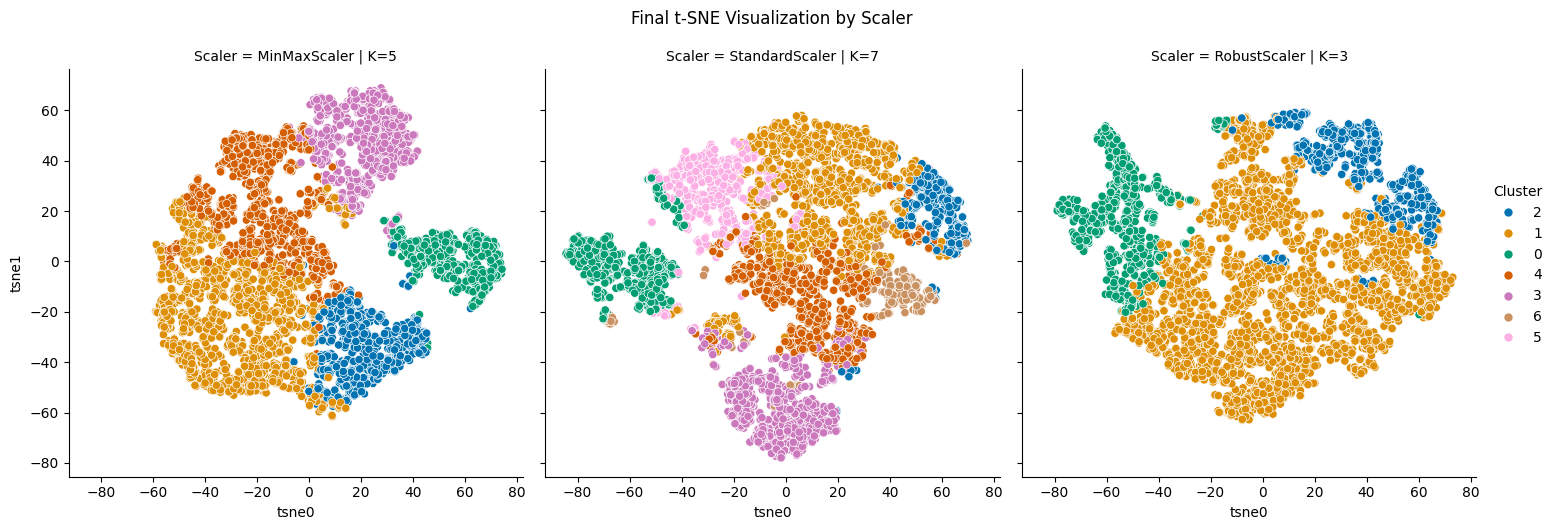

In [ ]:
tsne_df = plot_final_tsne_by_scaler(pca_results)

DBSCAN to evaluate KMeans algorithm

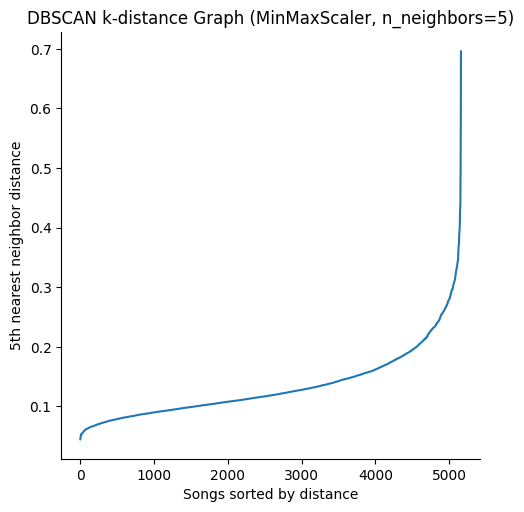

In [ ]:
 # DBSCAN Evaluation with MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
import matplotlib.pyplot as plt

scaler = MinMaxScaler()

scaled_songs_df = scaler.fit_transform(songs_df)
pca = PCA(n_components=0.95)
pca_df = pca.fit_transform(scaled_songs_df)

neighbors = NearestNeighbors(n_neighbors=5)

neighbors.fit(pca_df)

distances, indices = neighbors.kneighbors(pca_df)

fifth_distances = distances[:, 4]

sorted_distances = sorted(fifth_distances)


sns.relplot(
    x=range(len(sorted_distances)),
    y=sorted_distances,
    kind="line"
)

plt.xlabel("Songs sorted by distance")
plt.ylabel("5th nearest neighbor distance")

plt.title(
    "DBSCAN k-distance Graph (MinMaxScaler, n_neighbors=5)"
)

plt.show()

In [ ]:
#eps = 0.02 n_neighbors=5
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.2,
    min_samples=3
)

labels_2 = dbscan.fit_predict(pca_df)

pca_df["Cluster_2"] = labels_2

pca_df["Cluster_2"].value_counts()

,count
Cluster_2,
0,4851
-1,258
5,5
4,4
3,4
12,4
14,4
2,3
1,3


Since DBSCAN did not produce clear and interpretable playlist structures for the Moosic use case, we decided to continue with KMeans as the main clustering algorithm.

Based on the previous evaluations, we will focus on comparing MinMaxScaler with K=5 and StandardScaler with K=7 to determine which configuration provides the best cluster separation and playlist quality.

In [ ]:
# MINMAXSCALER - K=5

minmax_data = pca_results["MinMaxScaler"]

model_minmax = KMeans(n_clusters=5, random_state=42)
labels_minmax = model_minmax.fit_predict(minmax_data)

minmax_df = minmax_data.iloc[:, :2].copy()
minmax_df.columns = ["PC1", "PC2"]
minmax_df["Cluster"] = labels_minmax.astype(str)


# STANDARDSCALER - K=7

standard_data = pca_results["StandardScaler"]

model_standard = KMeans(n_clusters=7, random_state=42)
labels_standard = model_standard.fit_predict(standard_data)

standard_df = standard_data.iloc[:, :2].copy()
standard_df.columns = ["PC1", "PC2"]
standard_df["Cluster"] = labels_standard.astype(str)

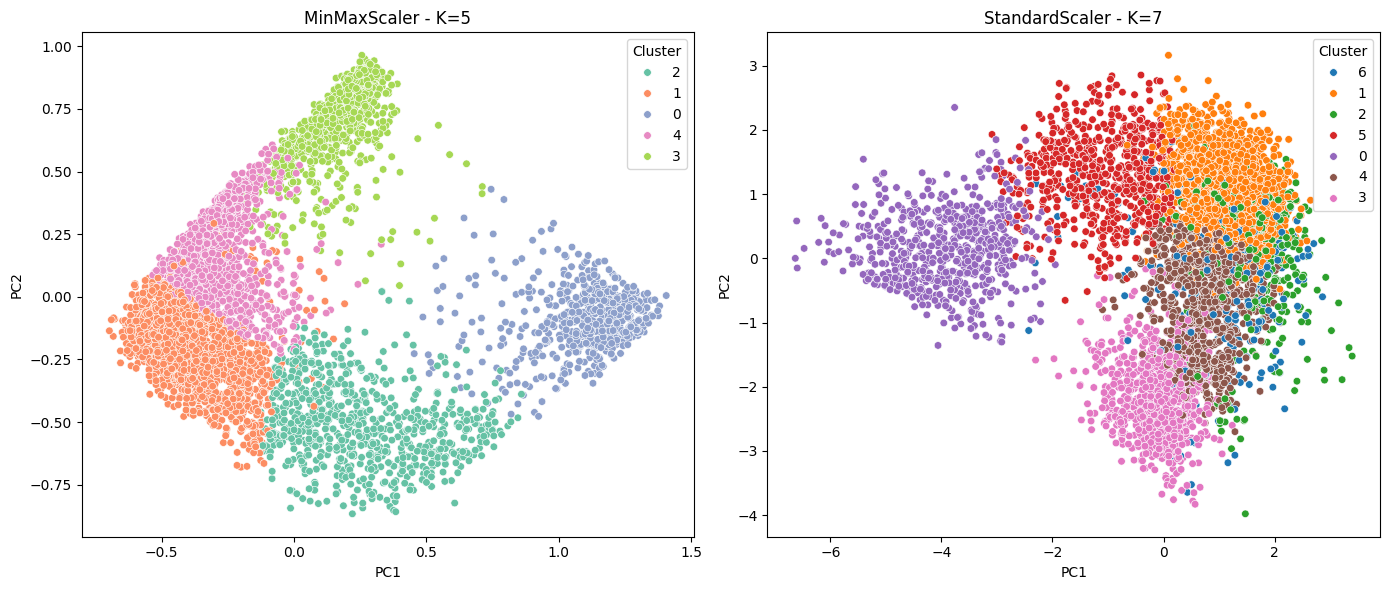

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(
    data=minmax_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    ax=axes[0],
    s=30
)

axes[0].set_title("MinMaxScaler - K=5")

sns.scatterplot(
    data=standard_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    ax=axes[1],
    s=30
)

axes[1].set_title("StandardScaler - K=7")

plt.tight_layout()
plt.show()

**MinMaxScaler with K=5 **produced the clearest and most interpretable cluster structure. The clusters are compact, better separated, and visually easier to distinguish.

In contrast, StandardScaler with K=7 generated more overlapping groups, making playlist segmentation less clear for recommendation purposes.

In [ ]:
# Song Clusters Analysis:
# Number of Songs per Cluster and Cluster Interpretation

scaler = MinMaxScaler()
scaled_songs_df = scaler.fit_transform(songs_df)

pca = PCA(n_components=0.95)
pca_scaled_songs_df = pca.fit_transform(scaled_songs_df)

model = KMeans(
    n_clusters=5,
    random_state=42
)

labels = model.fit_predict(pca_scaled_songs_df)

songs_clustered = songs_df.copy()
songs_clustered["labels"] = labels

songs_clustered.groupby("labels").size()

,0
labels,
0,603
1,1764
2,774
3,887
4,1132


In [ ]:
songs_clustered.groupby("labels").mean()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
labels,,,,,,,,,
0,0.323272,0.135609,-21.914585,0.045332,0.930653,0.858924,0.134504,0.170074,105.304320
1,0.703635,0.726137,-6.571960,0.092433,0.168772,0.021198,0.178113,0.722660,119.378452
2,0.522644,0.359208,-12.233738,0.055108,0.743161,0.038166,0.182049,0.457180,114.444904
3,0.301345,0.892964,-8.135779,0.099702,0.016024,0.789871,0.203864,0.258584,122.499869
4,0.450829,0.828648,-6.108118,0.094982,0.049074,0.052828,0.211587,0.283555,124.540017


In [ ]:
# Moosic Playlist Recommendations by Label( base on the mean's analysis on claude and chatgpt )

cluster_interpretation = pd.DataFrame({

    "Characteristics": [
        "Very high acousticness (0.93), very high instrumentalness (0.86), very low energy (0.14), very low loudness (-21)",

        "High danceability (0.71), high energy (0.73), high valence (0.73), loudness (-6.6)",

        "Very high energy (0.82), high loudness (-6.1), high tempo (125), medium danceability (0.46)",

        "Very high energy (0.89), high liveness (0.79), intense sound, high tempo (122)",

        "High acousticness (0.75), medium danceability (0.52), softer energy (0.36), neutral/relaxed mood"
    ],

    "Moosic Playlist Type": [
        "🎻 Acoustic Focus & Instrumental",
        "🕺 Dance Party Hits",
        "🤘 High Energy Rock & Workout",
        "🎤 Live Concert Energy",
        "🌙 Chill Acoustic Vibes"
    ]

},

index=[
    "Label 0",
    "Label 1",
    "Label 2",
    "Label 3",
    "Label 4"
])

cluster_interpretation

,Characteristics,Moosic Playlist Type
Label 0,"Very high acousticness (0.93), very high instr...",🎻 Acoustic Focus & Instrumental
Label 1,"High danceability (0.71), high energy (0.73), ...",🕺 Dance Party Hits
Label 2,"Very high energy (0.82), high loudness (-6.1),...",🤘 High Energy Rock & Workout
Label 3,"Very high energy (0.89), high liveness (0.79),...",🎤 Live Concert Energy
Label 4,"High acousticness (0.75), medium danceability ...",🌙 Chill Acoustic Vibes


In [ ]:
# Playlist counts with labels

playlist_summary = pd.DataFrame({
    "Label":[0, 1,2, 3, 4],

    "Moosic Playlist Type": [
        "🎻 Acoustic Focus & Instrumental",
        "🕺 Dance Party Hits",
        "🤘 High Energy Rock & Workout",
        "🎤 Live Concert Energy",
        "🌙 Chill Acoustic Vibes"
    ],
    "Number of songs":[604, 1790, 1174, 893, 774]

})

playlist_summary

,Label,Moosic Playlist Type,Number of songs
0,0,🎻 Acoustic Focus & Instrumental,604
1,1,🕺 Dance Party Hits,1790
2,2,🤘 High Energy Rock & Workout,1174
3,3,🎤 Live Concert Energy,893
4,4,🌙 Chill Acoustic Vibes,774


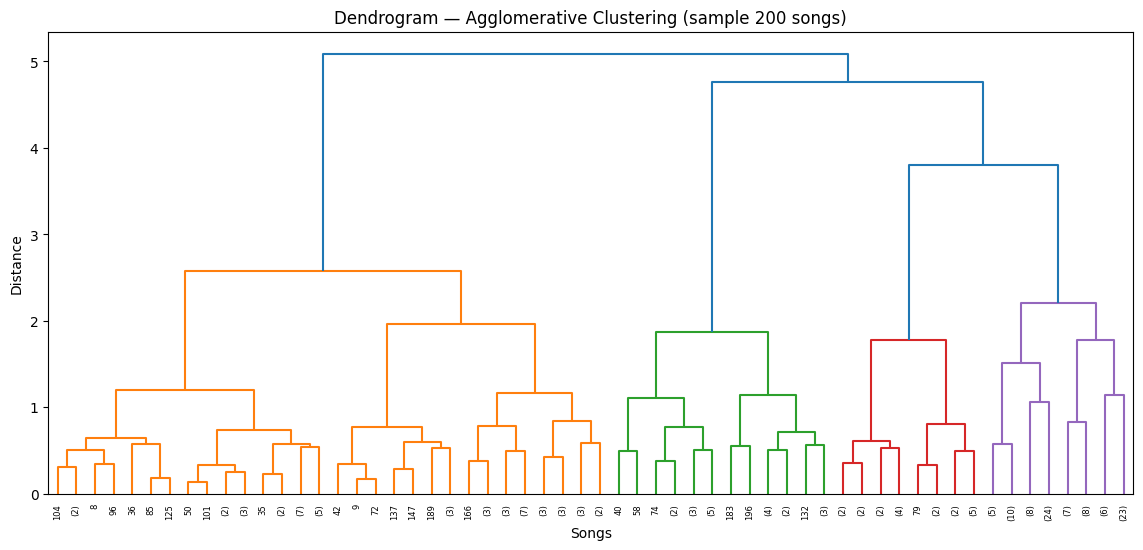

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

sample = pca_results["MinMaxScaler"][:200]

linked = linkage(sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Dendrogram — Agglomerative Clustering (sample 200 songs)")
plt.xlabel("Songs")
plt.ylabel("Distance")
plt.show()